# Business Insight / Time Series Analysis

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clean/clean_data.csv")

## -Order per month 2023 (Most Data Set)

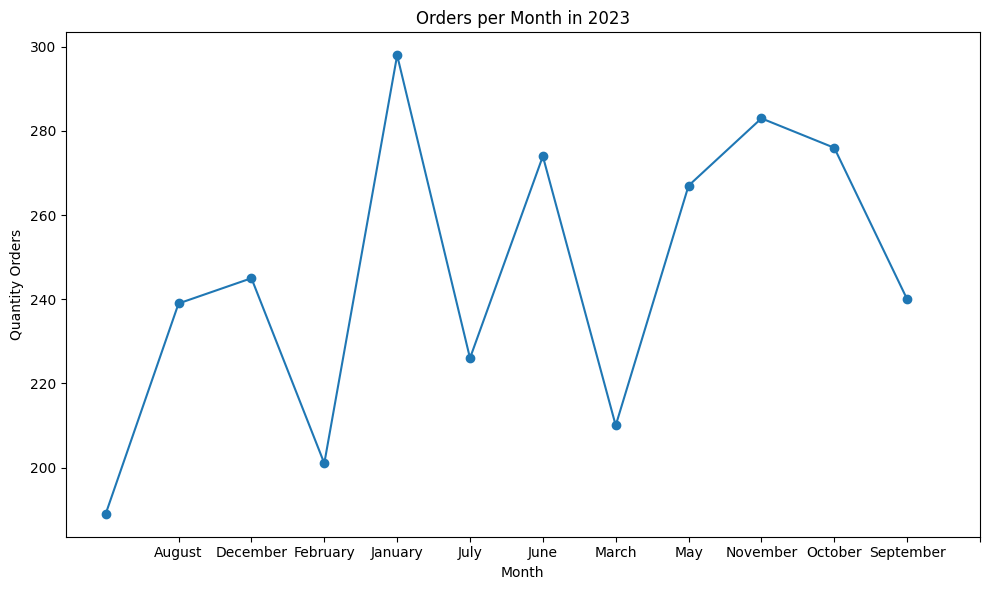

In [23]:
orders_2023 = (
    df[df["Year"] == 2023]
    .groupby("Month_name")["Quantity"]
    .sum()
)


plt.figure(figsize=(10, 6))
plt.plot(orders_2023.index, orders_2023.values, marker="o")

plt.title("Orders per Month in 2023")
plt.xlabel("Month")
plt.ylabel("Quantity Orders")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

## -Order per Day 2023 (List Percentage each Day)

- we measure to find out each day percentage to be view point the topest is the most order date to the less down step

In [24]:
df_2023 = df[df["Year"] == 2023].copy()

df_2023["Day"] = df_2023["Order Date"].dt.day

In [28]:
daily_mean_2023 = (
    df_2023
    .groupby("Day")["Quantity"]
    .mean()
    .sort_values(ascending=False)
)

print(daily_mean_2023)

Day
12    3.346154
22    3.343750
7     3.285714
31    3.277778
17    3.250000
4     3.227273
3     3.219512
18    3.216216
24    3.166667
9     3.125000
20    3.085714
11    3.066667
2     3.064516
1     3.054054
15    3.043478
29    3.041667
8     3.026316
30    3.000000
14    2.970588
28    2.926829
6     2.921053
19    2.892857
16    2.883721
21    2.870968
25    2.828571
5     2.827586
27    2.827586
13    2.735294
26    2.714286
10    2.645161
23    2.625000
Name: Quantity, dtype: float64


จากข้อมูล เราเห็นได้ว่า วันที่ 12 ,22, 7, 31 คือ วันที่มีการ orders มากที่สุด ของปี 2023 ซึ่งวัดจากค่าเฉลี่ย  เพื่อ วิเคราะห์เบื้องลึกต่อไป ซึ่ง เดือนที่มากที่สุด คือ มกราคม, 

##### ด่านล่างคือ จํานวนเดือน ของ ปี2023 - 2024 ซึ่ง ปี 2024 มีเดือนไม่ครบ และ ต้องวิเคราะห์เจาะจง เช่น เทียบเดือน กับ เดือนเดียวกัน ของปี ก่อน และ อาจจะ วิเคราะห์ trend ต่อได้ เพื่อไช้กับ การสร้างโมเดลทํานาย


In [31]:
df.groupby("Year")["Month_name"].unique().apply(sorted)

Year
2023    [April, August, December, February, January, J...
2024                                            [January]
Name: Month_name, dtype: object

In [33]:
df.groupby(["Year", "Month_name"])["Order Date"].nunique()

Year  Month_name
2023  April         27
      August        27
      December      27
      February      27
      January       31
      July          29
      June          29
      March         28
      May           29
      November      30
      October       27
      September     28
2024  January        1
Name: Order Date, dtype: int64

ความไม่เหมาะสม เราไม่สามารถวสิเคราะห์ของ ปี 2024 แล้ว และ อาจจะตัดทิ้งได้ด้วยซํ้า เพราะ ขนาด Data size ของปี 2024 ไม่มีประโยชน์ มี แค่ 1 วัน ซึ่ง เราสามารถ ตัดทิ้ง หรือ ปล่อยผ่านได้เลย และ ต่อไปของ การวิเคราะห์ เรา จะ วิเคราะห์ได้ แค่ ของ ปี2023 เท่านั้น